# 06 — K-Nearest Neighbors (KNN)

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 6 of 20**

KNN is conceptually the simplest algorithm in this sprint: it doesn't really "learn" a model in the
sense Linear/Logistic Regression do — it just **memorizes the training data** and, at prediction time,
looks at which stored examples are closest to the new point.

**Datasets:** `load_breast_cancer` (classification, continuing from Notebook 5) and `load_diabetes`
(regression, continuing from Notebooks 3-4) — both fully bundled, no network download — so this
notebook can show KNN used for *both* problem types, as the sprint brief asks.


## 1. What is KNN?

**K-Nearest Neighbors** predicts a new point by finding the **K training examples closest to it** (by
some distance measure) and combining their known labels/values:
- **Classification**: majority vote among the K neighbors' classes.
- **Regression**: average (or weighted average) of the K neighbors' target values.

There is no training phase in the usual sense — `fit()` for KNN just stores the training data. All the
computation happens at prediction time ("lazy learning"), which is the opposite of Linear/Logistic
Regression, where `fit()` does all the work up front and `predict()` is nearly instant.

**Why is it required / what problem does it solve?** It makes almost no assumptions about the shape of
the relationship between features and target (no linearity assumption, unlike Notebooks 4-5) — it lets
the *local structure of the data itself* define the decision boundary or regression surface, which can
capture patterns a linear model simply cannot represent.

**Assumptions:** that "closeness" in feature space genuinely implies similarity in outcome — points
near each other should have similar labels/values. This assumption breaks down in high dimensions
(the "curse of dimensionality" — with enough features, every point ends up roughly equidistant from
every other point, and "nearest" stops being meaningful) and when features aren't scaled comparably
(Section 5).

**When to use it:** small-to-medium datasets, when you suspect the true relationship is non-linear or
irregular, and when you want a simple, no-training-cost baseline with no real training phase.
**When not to use it:** large datasets (prediction time scales with training-set size — every prediction
requires comparing against every stored point, unless you use spatial indexing tricks), high-dimensional
data (curse of dimensionality), or when you need a fast, low-memory model to deploy (KNN must carry the
entire training set with it).


## 2. Distance — how "nearest" is measured

The most common choice is **Euclidean distance** — ordinary straight-line distance, generalizing the
Pythagorean theorem to $n$ dimensions:

$$d(a, b) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

Other distance metrics exist (Manhattan/city-block distance, Minkowski distance of which Euclidean is a
special case, cosine distance for text/high-dimensional sparse data) — scikit-learn's `KNeighborsClassifier`
and `KNeighborsRegressor` default to Euclidean but accept a `metric` parameter to change this.


Point a = [1 2], point b = [4 6]
Euclidean distance (manual)  = 5.0000
Euclidean distance (scipy)   = 5.0000


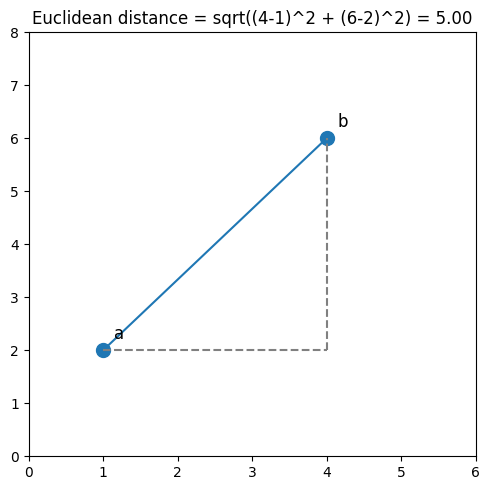

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# A tiny worked example: 2D points
a = np.array([1, 2])
b = np.array([4, 6])
print(f"Point a = {a}, point b = {b}")
print(f"Euclidean distance (manual)  = {euclidean_distance(a, b):.4f}")

from scipy.spatial.distance import euclidean
print(f"Euclidean distance (scipy)   = {euclidean(a, b):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([a[0], b[0]], [a[1], b[1]], "o-", markersize=10)
ax.annotate("a", a, textcoords="offset points", xytext=(8, 8), fontsize=12)
ax.annotate("b", b, textcoords="offset points", xytext=(8, 8), fontsize=12)
ax.plot([a[0], b[0]], [a[1], a[1]], "--", color="gray")   # horizontal leg
ax.plot([b[0], b[0]], [a[1], b[1]], "--", color="gray")   # vertical leg
ax.set_title(f"Euclidean distance = sqrt((4-1)^2 + (6-2)^2) = {euclidean_distance(a, b):.2f}")
ax.set_xlim(0, 6); ax.set_ylim(0, 8)
plt.tight_layout()
plt.savefig("euclidean_distance.png", dpi=120)
plt.show()


## 3. Choosing K

K is a **hyperparameter** (Notebook 1, Section 6) — you set it before training, it isn't learned.

- **Small K** (e.g., K=1): the prediction follows the training data very closely, including its noise
  — this tends toward **overfitting** (high variance: small changes in the training data can flip
  predictions for nearby query points).
- **Large K**: predictions get smoothed over many neighbors, including possibly irrelevant, far-away
  ones — this tends toward **underfitting** (high bias: the model becomes too "averaged out" to
  capture real local structure).
- K is usually chosen via cross-validation (Notebook 3) — try a range of values and pick whichever
  generalizes best on held-out folds, not whichever fits the training data best.

A common practical guideline: start around $K = \sqrt{m}$ (where $m$ is the number of training
examples) as a rough starting point, then tune from there; also prefer **odd** K for binary
classification to avoid tie votes.


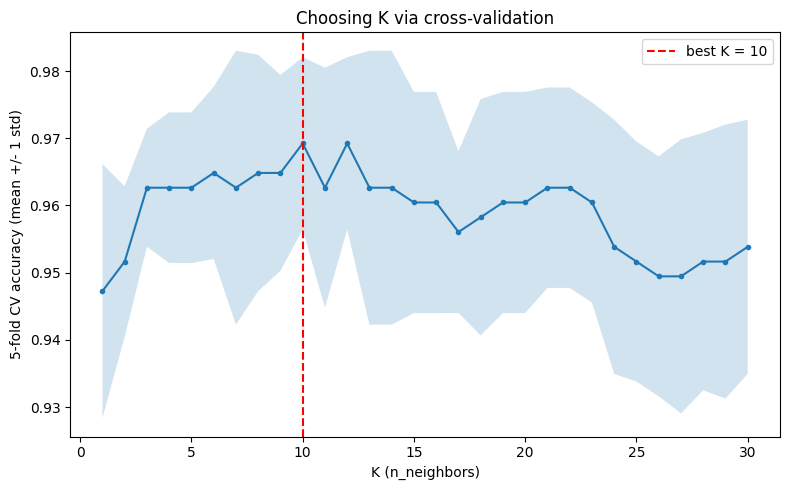

Best K by CV accuracy: 10  (CV accuracy = 0.9692)
K=1 CV accuracy:  0.9473   (likely overfit to training noise)
K=29 CV accuracy: 0.9538   (likely oversmoothed)


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer(as_frame=True)
Xc, yc = data.data, data.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=42)

k_values = range(1, 31)
cv_means, cv_stds = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, Xc_train, yc_train, cv=skf, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means, cv_stds = np.array(cv_means), np.array(cv_stds)
best_k = list(k_values)[cv_means.argmax()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), cv_means, marker="o", markersize=3)
ax.fill_between(list(k_values), cv_means - cv_stds, cv_means + cv_stds, alpha=0.2)
ax.axvline(best_k, color="red", linestyle="--", label=f"best K = {best_k}")
ax.set_xlabel("K (n_neighbors)")
ax.set_ylabel("5-fold CV accuracy (mean +/- 1 std)")
ax.set_title("Choosing K via cross-validation")
ax.legend()
plt.tight_layout()
plt.savefig("choosing_k.png", dpi=120)
plt.show()

print(f"Best K by CV accuracy: {best_k}  (CV accuracy = {cv_means.max():.4f})")
print(f"K=1 CV accuracy:  {cv_means[0]:.4f}   (likely overfit to training noise)")
print(f"K=29 CV accuracy: {cv_means[-1]:.4f}   (likely oversmoothed)")


## 4. KNN for Classification and for Regression

The same "find K nearest neighbors" mechanic works for both problem types — only the final aggregation
step differs (vote vs. average).


In [3]:
from sklearn.metrics import accuracy_score

# --- Classification, using the best K found above ---
best_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))])
best_pipe.fit(Xc_train, yc_train)
test_acc = accuracy_score(yc_test, best_pipe.predict(Xc_test))
print(f"KNN classifier (K={best_k}) test accuracy: {test_acc:.4f}")

# --- Regression ---
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error

diabetes = load_diabetes(as_frame=True)
Xr, yr = diabetes.data, diabetes.target
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=10))])
reg_pipe.fit(Xr_train, yr_train)
test_rmse = root_mean_squared_error(yr_test, reg_pipe.predict(Xr_test))
print(f"KNN regressor (K=10) test RMSE: {test_rmse:.2f}")

from sklearn.linear_model import LinearRegression
lr_rmse = root_mean_squared_error(yr_test, LinearRegression().fit(Xr_train, yr_train).predict(Xr_test))
print(f"(for comparison) Linear Regression test RMSE from Notebook 4: {lr_rmse:.2f}")


KNN classifier (K=10) test accuracy: 0.9649
KNN regressor (K=10) test RMSE: 56.29
(for comparison) Linear Regression test RMSE from Notebook 4: 53.85


**Reading the comparison:** on this particular dataset, plain Linear Regression edges out KNN —
that's a genuinely useful result, not a failure of the demo: it suggests the true relationship between
these 10 features and disease progression is close enough to linear that KNN's flexibility isn't buying
much, while KNN pays a real cost in the curse-of-dimensionality sense (10 features, only ~350 training
points). This is exactly the kind of comparison Notebook 18 (Model Comparison) formalizes — **more
flexible does not automatically mean better**.


## 5. Feature Scaling — why KNN requires it

KNN's predictions come entirely from **distances** between points. If one feature is measured in the
thousands (e.g., `worst area`, in square pixel-equivalents) and another ranges from 0 to 1 (e.g.,
`mean smoothness`), the large-scale feature will completely dominate the distance calculation — the
small-scale feature becomes nearly irrelevant to "nearest," regardless of how informative it actually
is. **Unlike Linear/Logistic Regression's coefficients** (which can compensate for feature scale by
just becoming larger or smaller), KNN has no such compensating mechanism — scaling isn't optional,
it's required for the distances to be meaningful at all.


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Same K, same data, same CV strategy -- only difference is whether StandardScaler is in the pipeline
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_scaled = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))])

scores_unscaled = cross_val_score(knn_unscaled, Xc_train, yc_train, cv=skf, scoring="accuracy")
scores_scaled = cross_val_score(knn_scaled, Xc_train, yc_train, cv=skf, scoring="accuracy")

print(f"KNN WITHOUT scaling: {scores_unscaled.mean():.4f} (+/- {scores_unscaled.std():.4f})")
print(f"KNN WITH scaling:    {scores_scaled.mean():.4f} (+/- {scores_scaled.std():.4f})")

# Show WHY: compare the raw scale of two features directly
print("\nRaw feature scales (this is what distance calculations see without scaling):")
print(Xc[["mean smoothness", "worst area"]].describe().loc[["min", "max", "std"]].round(2))


KNN WITHOUT scaling: 0.9363 (+/- 0.0128)
KNN WITH scaling:    0.9692 (+/- 0.0128)

Raw feature scales (this is what distance calculations see without scaling):
     mean smoothness  worst area
min             0.05      185.20
max             0.16     4254.00
std             0.01      569.36


**Reading this output:** `worst area`'s standard deviation is roughly 1000x `mean smoothness`'s
— in an unscaled Euclidean distance, `worst area` alone would decide almost every "nearest neighbor"
comparison, and `mean smoothness` would contribute almost nothing, regardless of its actual predictive
value. Scaling both to comparable ranges (mean 0, unit variance, via `StandardScaler`) lets every
feature contribute to distance roughly in proportion to how much it actually varies, not how large its
raw units happen to be. This is the same class of scale-sensitivity issue Notebook 3's data-leakage
section demonstrated for KNN specifically (Section 6 of that notebook) — feature scaling and leakage
discipline compound with each other, which is exactly why both live inside one `Pipeline`.


## 6. Advantages and Limitations

**Advantages**
- Simple to understand and implement; no training phase, so adding new data is trivial (no retraining
  needed — just add points to the stored set).
- Makes no assumption about the underlying relationship's shape (unlike Linear/Logistic Regression's
  linearity assumption) — can capture complex, irregular decision boundaries or regression surfaces.
- Naturally handles multiclass classification without any special extension (unlike Logistic
  Regression's One-vs-Rest/Softmax machinery from Notebook 5).

**Limitations**
- Slow at prediction time on large datasets (must compare against every stored training point, unless
  using spatial indexing structures like KD-trees/Ball-trees, which scikit-learn uses automatically
  where possible but which themselves degrade in high dimensions).
- Requires feature scaling (Section 5) — an easy step to forget.
- Suffers from the curse of dimensionality: with many features, all points become roughly equidistant
  and "nearest" loses meaning.
- Memory-heavy: the entire training set must be stored and carried into deployment.
- Sensitive to irrelevant/noisy features, since every feature contributes to distance unless explicitly
  removed or weighted (see Notebook 2's Feature Selection stage).


## 7. Summary — Key Takeaways

- KNN predicts by finding the K closest stored training points and voting (classification) or averaging
  (regression) their labels/values — there's no real "training," only storage.
- K is a hyperparameter tuned via cross-validation: too small overfits to noise, too large underfits by
  oversmoothing.
- Feature scaling is **required**, not optional, because predictions come directly from distance
  calculations that any unscaled large-magnitude feature would otherwise dominate.
- KNN trades training simplicity for prediction-time cost and memory, and degrades in high dimensions.


## 8. Try It Yourself (no solutions given)

1. Re-run Section 3's K-sweep using `metric="manhattan"` instead of the default Euclidean distance
   (pass `metric="manhattan"` to `KNeighborsClassifier`). Does the best K or the best CV accuracy change
   noticeably?
2. In Section 4, sweep `n_neighbors` for the KNN *regressor* on the diabetes data (try K = 1, 5, 10, 20,
   40) and plot test RMSE against K. Does it show the same "small K overfits, large K underfits" pattern
   the classification sweep showed in Section 3?
3. Using only 2 of the 30 breast-cancer features (pick two you think are informative, e.g. `mean
   radius` and `mean texture`), refit a KNN classifier and plot its actual decision regions the way
   Notebook 5 plotted Logistic Regression's — is the boundary a straight line, the way Logistic
   Regression's was? What does that tell you about what kinds of patterns KNN can represent that
   Logistic Regression can't?
4. Explain in your own words why "the entire training set must be carried into deployment" is a real
   practical cost, in a way that (for example) a trained Linear Regression model's handful of
   coefficients wouldn't be.
